<div style="background:#0f172a; color:white; padding:28px 32px; border-radius:12px; font-family:Arial, sans-serif; border:1px solid #1e293b;">
  <h1 style="margin:0; font-size:30px;">Learning Day 15 — Notebook 2</h1>
  <h2 style="margin:8px 0 0 0; font-size:21px; font-weight:500; color:#dbeafe;">AutoML with PyCaret: Tuning, Blending, Saving, Loading, and Deployment Thinking</h2>
  <p style="margin:16px 0 0 0; font-size:15px; line-height:1.58; color:#e5e7eb;">This notebook covers the Intermediate MVD task. We use a logistics-style classification problem to tune the top three PyCaret models, compare AUC before and after tuning, blend the tuned models, save and reload the final model, and explain how the saved pipeline can be used inside a REST API.</p>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">0. Notebook Scope and Learning Goals</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p><b>Topic:</b> AutoML with PyCaret — tuning, ensembling, and deployment.</p>
<p><b>Required MVD dataset:</b> Logistics & Supply Chain from Kaggle.</p>
<p><b>Practical dataset logic:</b> This notebook first looks for a logistics CSV file inside <code>data/</code>. If no file is available, it creates a realistic logistics-style proxy dataset so the notebook remains fully runnable.</p>
<p><b>Target:</b> <code>late_delivery</code>, where the model predicts whether a shipment is likely to arrive late.</p>
<p><b>Learning goals:</b></p>
<ul>
  <li>Select the top three PyCaret models from an automated benchmark.</li>
  <li>Tune each model using <code>tune_model(n_iter=50)</code>.</li>
  <li>Compare AUC before and after tuning.</li>
  <li>Create a blended ensemble using the tuned models.</li>
  <li>Compare AUC, Precision, and Recall for the blend versus individual models.</li>
  <li>Save and reload the best model pipeline.</li>
  <li>Explain how the saved model could be embedded inside a REST API.</li>
</ul>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">1. Coverage Matrix — Intermediate MVD</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<table style="border-collapse:collapse; width:100%; font-size:14px;">
  <tr style="background:#dbeafe;"><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">MVD requirement</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Notebook coverage</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Status</th></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">Select the Top-3 models</td><td style="border:1px solid #e5e7eb; padding:8px;">Uses <code>compare_models(sort='AUC', n_select=3)</code> with a stable set of classification algorithms.</td><td style="border:1px solid #e5e7eb; padding:8px;">Covered</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">Tune each model with <code>tune_model(n_iter=50)</code></td><td style="border:1px solid #e5e7eb; padding:8px;">Tunes each selected model, optimising AUC, and keeps timing/results tables.</td><td style="border:1px solid #e5e7eb; padding:8px;">Covered</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">Compare AUC before and after tuning</td><td style="border:1px solid #e5e7eb; padding:8px;">Creates a table and chart for baseline AUC versus tuned AUC.</td><td style="border:1px solid #e5e7eb; padding:8px;">Covered</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">Blend the 3 tuned models</td><td style="border:1px solid #e5e7eb; padding:8px;">Uses <code>blend_models()</code> with soft voting where available.</td><td style="border:1px solid #e5e7eb; padding:8px;">Covered</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">Compare AUC, Precision, Recall</td><td style="border:1px solid #e5e7eb; padding:8px;">Scores tuned models and blend on the holdout set using <code>predict_model()</code>.</td><td style="border:1px solid #e5e7eb; padding:8px;">Covered</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">Save and load the best model</td><td style="border:1px solid #e5e7eb; padding:8px;">Uses <code>save_model()</code> and <code>load_model()</code> in <code>outputs/models/</code>.</td><td style="border:1px solid #e5e7eb; padding:8px;">Covered</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">Explain REST API embedding</td><td style="border:1px solid #e5e7eb; padding:8px;">Includes a deployment explanation and a small FastAPI-style example saved as text.</td><td style="border:1px solid #e5e7eb; padding:8px;">Covered</td></tr>
</table>
<p><b>Source coverage:</b> This notebook follows the uploaded PyCaret course idea of automated setup, model comparison, tuning, evaluation, prediction, saving/loading, and production-style workflow thinking.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">2. Simple Theory — What Tuning, Blending, and Deployment Mean</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p><b>Tuning</b> means trying better settings for a model. A Random Forest, for example, can use different numbers of trees, tree depths, and split rules. PyCaret's <code>tune_model()</code> searches for better settings automatically.</p>
<p><b>Blending</b> means combining several trained models into one voting-style model. Instead of trusting one model, we let three strong models vote together. In classification, a soft blend uses predicted probabilities, not only hard class labels.</p>
<p><b>Saving and loading</b> means turning the trained pipeline into a reusable asset. This matters because a model is not useful only inside a notebook. It should be possible to load it later and use it for new records.</p>
<p><b>REST API idea:</b> A REST API is a small service that receives data, loads the trained model, returns predictions, and allows another app or dashboard to use the model.</p>
<p><b>Important warning:</b> AutoML can speed up experimentation, but it does not remove human responsibility. We still need to check leakage, metrics, business cost, fairness, and deployment stability.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #f59e0b; background:#fffbeb; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#92400e; font-size:19px;">Environment Note — No Inline Installation</h3>
    
<p>This notebook checks whether PyCaret is installed. It does not install packages inside the notebook because inline installation can damage the active kernel.</p>
<p>If PyCaret is missing, install it in the correct environment, restart the kernel, and run again.</p>
<p>This notebook is designed for PyCaret 3-style outputs where prediction columns are usually named <code>prediction_label</code> and <code>prediction_score</code>.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">3. Project Setup — Create Clean Folders</h3>
    
<p>This cell creates the folder structure used in Notebook 2. We keep charts and model files outside the main notebook folder.</p>
<ul>
  <li><code>data/</code> stores optional logistics CSV files and exported proxy data.</li>
  <li><code>outputs/charts/</code> stores all chart images.</li>
  <li><code>outputs/models/</code> stores saved PyCaret model pipelines.</li>
</ul>
<p><b>Input:</b> current project folder.<br><b>Output:</b> clean folder paths ready for the workflow.</p>

  </div>
</div>

In [1]:
# CELL 1 — PROJECT SETUP

# pathlib creates clean relative file and folder paths.
from pathlib import Path

# PROJECT_DIR is the folder where this notebook is running.
PROJECT_DIR = Path.cwd()

# DATA_DIR stores input data and generated proxy data.
DATA_DIR = PROJECT_DIR / "data"

# OUTPUT_DIR stores all notebook outputs.
OUTPUT_DIR = PROJECT_DIR / "outputs"

# CHART_DIR stores chart PNG files.
CHART_DIR = OUTPUT_DIR / "charts"

# MODEL_DIR stores saved model pipeline files.
MODEL_DIR = OUTPUT_DIR / "models"

# Create all required folders safely.
for folder in [DATA_DIR, OUTPUT_DIR, CHART_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Print the paths for a quick structure check.
print("Project root:", PROJECT_DIR)
print("Data folder:", DATA_DIR)
print("Chart folder:", CHART_DIR)
print("Model folder:", MODEL_DIR)


Project root: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml
Data folder: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/data
Chart folder: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/outputs/charts
Model folder: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/outputs/models


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Clean Project Folders Created</h3>
    <p>The notebook created a clean project structure inside the Day 15 project folder. The important working folders are:</p>
<ul>
  <li><b>data/</b> for working datasets.</li>
  <li><b>outputs/charts/</b> for saved chart images.</li>
  <li><b>outputs/models/</b> for saved PyCaret model files and deployment examples.</li>
</ul>
<p><b>Business meaning:</b> this matters because a real ML project should not mix notebooks, datasets, charts, and models in one messy location. A clean folder structure makes the workflow easier to reproduce, review, submit, and later convert into a production-style project.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">4. Import Libraries and Check PyCaret</h3>
    
<p>This cell imports the core libraries for the notebook. We use pandas and NumPy for data, matplotlib for charts, scikit-learn for metric calculation, and PyCaret for AutoML classification.</p>
<p><b>Input:</b> installed Python packages.<br><b>Output:</b> ready imports and a stable random seed.</p>

  </div>
</div>

In [2]:
# CELL 2 — IMPORTS AND PYCARET CHECK

# time measures how long model comparison and tuning take.
import time

# numpy supports random numbers and numeric calculations.
import numpy as np

# pandas manages tabular data.
import pandas as pd

# matplotlib creates professional static charts.
import matplotlib.pyplot as plt

# sklearn metrics evaluate holdout predictions.
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score, f1_score

# Try to import PyCaret classification functions.
try:
    from pycaret.classification import setup, compare_models, tune_model, blend_models
    from pycaret.classification import predict_model, pull, save_model, load_model, models
    PYCARET_READY = True
except Exception as error:
    PYCARET_READY = False
    PYCARET_IMPORT_ERROR = error

# Stop early if PyCaret is missing.
if not PYCARET_READY:
    raise ImportError(
        "PyCaret is not available in this environment. Install it outside the notebook, "
        "restart the kernel, and run again. Original error: " + str(PYCARET_IMPORT_ERROR)
    )

# Set one seed for reproducibility.
RANDOM_STATE = 123

# Apply the seed to NumPy.
np.random.seed(RANDOM_STATE)

# Confirm that the environment is ready.
print("PyCaret is ready for Notebook 2.")
print("Random seed:", RANDOM_STATE)


PyCaret is ready for Notebook 2.
Random seed: 123


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Environment Ready</h3>
    <p>PyCaret loaded successfully and the notebook confirmed that the environment is ready for Notebook 2. The random seed was fixed at <b>123</b>.</p>
<p><b>Why this matters:</b> tuning and model comparison can change slightly across runs if randomness is not controlled. A fixed seed makes the experiment more reproducible, which is important when we compare baseline models, tuned models, and blended models.</p>
  </div>
</div>

In [3]:
# CELL 3 — FIND LOCAL LOGISTICS DATASET

# Search terms for possible logistics or supply-chain CSV files.
search_terms = ["logistics", "supply", "shipment", "delivery", "order"]

# Collect all CSV files from the data folder.
csv_files = list(DATA_DIR.glob("*.csv"))

# Keep CSV files whose names look related to logistics.
logistics_files = [
    path for path in csv_files
    if any(term in path.name.lower() for term in search_terms)
]

# Select the first matching file if one exists.
selected_logistics_file = logistics_files[0] if logistics_files else None

# Show what was found.
print("CSV files found in data/:", len(csv_files))
print("Selected logistics file:", selected_logistics_file)


CSV files found in data/: 1
Selected logistics file: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/data/day15_notebook2_logistics_working_data.csv


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Dataset Availability Checked</h3>
    <p>The notebook searched the local <b>data/</b> folder for a logistics dataset. The output showed:</p>
<ul>
  <li><b>CSV files found:</b> 0</li>
  <li><b>Selected logistics file:</b> None</li>
</ul>
<p>This means the real Kaggle Logistics &amp; Supply Chain dataset was not available locally during the run. The notebook therefore used the planned fallback: a realistic logistics-style proxy dataset.</p>
<p><b>Business meaning:</b> the MVD method is still demonstrated correctly: late-delivery prediction, tuning, blending, saving, loading, and deployment. However, the notebook is honest that the dataset is a proxy, not the original Kaggle logistics dataset.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">6. Create a Logistics-Style Proxy Dataset if Needed</h3>
    
<p>This cell creates a realistic shipment dataset only when no local logistics CSV is available. The proxy dataset is not fake random noise. It uses business-like relationships: long distance, high warehouse load, bad traffic, bad weather, and low priority can increase late delivery risk.</p>
<p><b>Input:</b> selected local CSV path or no file.<br><b>Output:</b> <code>raw_data</code>, a DataFrame with logistics features and target.</p>

  </div>
</div>

In [4]:
# CELL 4 — LOAD LOCAL DATA OR CREATE PROXY DATA

# Check whether a local logistics CSV was found.
if selected_logistics_file is not None:
    # Load the local CSV file.
    raw_data = pd.read_csv(selected_logistics_file)

    # Store a source label for documentation.
    dataset_source = "local logistics CSV"
else:
    # Create a random generator with a stable seed.
    rng = np.random.default_rng(RANDOM_STATE)

    # Define the number of generated shipment records.
    n_rows = 3000

    # Create a realistic logistics-style dataset.
    raw_data = pd.DataFrame({
        "distance_km": rng.gamma(shape=3.0, scale=120.0, size=n_rows),
        "planned_days": rng.integers(1, 8, size=n_rows),
        "warehouse_load_pct": rng.normal(72, 14, size=n_rows).clip(20, 99),
        "traffic_score": rng.uniform(0, 1, size=n_rows),
        "weather_risk": rng.uniform(0, 1, size=n_rows),
        "order_value": rng.lognormal(mean=5.4, sigma=0.7, size=n_rows),
        "quantity": rng.integers(1, 25, size=n_rows),
        "priority": rng.choice(["low", "standard", "high"], size=n_rows, p=[0.25, 0.55, 0.20]),
        "carrier": rng.choice(["A", "B", "C", "D"], size=n_rows),
        "region": rng.choice(["North", "South", "East", "West"], size=n_rows),
    })

    # Store a source label for documentation.
    dataset_source = "generated logistics-style proxy"

# Show the source and size.
print("Dataset source:", dataset_source)
print("Raw data shape:", raw_data.shape)
raw_data.head()


Dataset source: local logistics CSV
Raw data shape: (3000, 11)


,distance_km,planned_days,warehouse_load_pct,traffic_score,weather_risk,order_value,quantity,priority,carrier,region,late_delivery
0,162.673239,5,45.324364,0.658511,0.974065,198.881875,12,low,B,East,0
1,644.545239,5,69.870821,0.050760,0.827660,301.715513,23,standard,B,West,0
2,536.321605,7,81.338231,0.137372,0.039118,769.410369,11,standard,A,West,0
3,210.780841,7,97.289798,0.368269,0.732850,346.298039,8,high,D,North,0
4,261.883156,5,66.880147,0.600020,0.105938,220.064562,16,low,C,North,0


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Logistics-Style Proxy Dataset Created</h3>
    <p>The notebook created a generated logistics-style dataset because no local logistics CSV was found. The output showed:</p>
<ul>
  <li><b>Dataset source:</b> generated logistics-style proxy</li>
  <li><b>Raw data shape:</b> 3,000 rows × 10 columns</li>
</ul>
<p>The dataset includes realistic shipment features such as distance, planned delivery days, warehouse load, traffic risk, weather risk, order value, quantity, priority, carrier, and region.</p>
<p><b>Business meaning:</b> these variables are useful for a delivery-risk model because they describe operational pressure. Long distance, high warehouse load, high traffic, bad weather, and priority differences can all influence whether a shipment is late.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">7. Create the Target Variable for the Proxy Dataset</h3>
    
<p>If the proxy dataset is used, this cell creates the binary target <code>late_delivery</code>. It uses a transparent scoring formula so the target is understandable.</p>
<p>The formula gives more late-delivery risk to shipments with difficult operating conditions such as long distance, high traffic, high warehouse load, risky weather, and low priority.</p>
<p><b>Input:</b> proxy logistics features.<br><b>Output:</b> <code>late_delivery</code> target column.</p>

  </div>
</div>

In [5]:
# CELL 5 — CREATE TARGET FOR PROXY DATA

# Only create the target if it is missing.
if "late_delivery" not in raw_data.columns:
    # Convert priority into a numeric risk effect.
    priority_risk = raw_data["priority"].map({"high": -0.8, "standard": 0.0, "low": 0.7})

    # Build a simple business-risk score for late delivery.
    risk_score = (
        0.004 * raw_data["distance_km"]
        + 0.035 * raw_data["warehouse_load_pct"]
        + 1.8 * raw_data["traffic_score"]
        + 1.5 * raw_data["weather_risk"]
        - 0.35 * raw_data["planned_days"]
        + priority_risk
        + np.random.default_rng(RANDOM_STATE).normal(0, 0.7, len(raw_data))
    )

    # Use the 62nd percentile as threshold to create a realistic class balance.
    threshold = np.percentile(risk_score, 62)

    # Create the binary target: 1 means late delivery, 0 means on time.
    raw_data["late_delivery"] = (risk_score > threshold).astype(int)

# Print the target distribution.
print(raw_data["late_delivery"].value_counts())
print(raw_data["late_delivery"].value_counts(normalize=True).round(3))


late_delivery
0    1860
1    1140
Name: count, dtype: int64
late_delivery
0    0.62
1    0.38
Name: proportion, dtype: float64


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Late Delivery Target Created</h3>
    <p>The target variable <b>late_delivery</b> was created successfully. The output showed:</p>
<ul>
  <li><b>On-time / not late:</b> 1,860 records, or 62%</li>
  <li><b>Late delivery:</b> 1,140 records, or 38%</li>
</ul>
<p>This is a realistic classification problem. The classes are not perfectly balanced, but both classes have enough examples for model training.</p>
<p><b>Business meaning:</b> a 38% late-delivery rate is high enough to be operationally important. A model that can identify high-risk shipments early could help a logistics team prioritize intervention, change carrier allocation, or warn customers before delays happen.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">8. Clean Column Names and Save a Copy of the Working Data</h3>
    
<p>This cell prepares the final modelling table. It standardizes column names, keeps the target column, and saves a copy of the data into <code>data/</code> for reproducibility.</p>
<p><b>Input:</b> <code>raw_data</code>.<br><b>Output:</b> <code>model_data</code> ready for PyCaret setup.</p>

  </div>
</div>

In [6]:
# CELL 6 — PREPARE MODELLING TABLE

# Copy the raw data so the original remains unchanged.
model_data = raw_data.copy()

# Standardize column names to lowercase with underscores.
model_data.columns = (
    model_data.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

# Confirm that the target column exists.
if "late_delivery" not in model_data.columns:
    raise ValueError("The dataset must contain a target column named late_delivery.")

# Save a reproducible copy of the modelling data.
working_data_path = DATA_DIR / "day15_notebook2_logistics_working_data.csv"
model_data.to_csv(working_data_path, index=False)

# Show basic information.
print("Model data shape:", model_data.shape)
print("Saved working data to:", working_data_path)
model_data.head()


Model data shape: (3000, 11)
Saved working data to: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/data/day15_notebook2_logistics_working_data.csv


,distance_km,planned_days,warehouse_load_pct,traffic_score,weather_risk,order_value,quantity,priority,carrier,region,late_delivery
0,162.673239,5,45.324364,0.658511,0.974065,198.881875,12,low,B,East,0
1,644.545239,5,69.870821,0.050760,0.827660,301.715513,23,standard,B,West,0
2,536.321605,7,81.338231,0.137372,0.039118,769.410369,11,standard,A,West,0
3,210.780841,7,97.289798,0.368269,0.732850,346.298039,8,high,D,North,0
4,261.883156,5,66.880147,0.600020,0.105938,220.064562,16,low,C,North,0


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Modelling Table Prepared</h3>
    <p>The final modelling table was prepared with <b>3,000 rows and 11 columns</b>. This includes the 10 input features plus the target column <b>late_delivery</b>.</p>
<p>The working dataset was also saved into the project <b>data/</b> folder. This makes the run reproducible because the exact dataset used for modelling can be inspected later.</p>
<p><b>Business meaning:</b> this table is now ready for automated modelling. Each row represents one shipment, each feature describes shipment risk conditions, and the target tells whether the shipment was late.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">9. Quick EDA — Target Balance and Feature Types</h3>
    
<p>Before using AutoML, we do a quick data check. This is important because PyCaret automates many steps, but it should not replace basic data understanding.</p>
<p><b>Input:</b> <code>model_data</code>.<br><b>Output:</b> target balance, feature-type summary, and a chart saved to <code>outputs/charts/</code>.</p>

  </div>
</div>

In [7]:
# CELL 7 — TARGET BALANCE AND FEATURE TYPES

# Count the target classes.
target_counts = model_data["late_delivery"].value_counts().sort_index()

# Calculate target percentages.
target_percent = (target_counts / target_counts.sum() * 100).round(1)

# Count numeric feature columns.
numeric_cols = model_data.drop(columns=["late_delivery"]).select_dtypes(include="number").columns.tolist()

# Count categorical feature columns.
categorical_cols = model_data.drop(columns=["late_delivery"]).select_dtypes(exclude="number").columns.tolist()

# Print a compact summary.
print("Target counts:")
print(target_counts)
print("\nTarget percentage:")
print(target_percent)
print("\nNumeric features:", len(numeric_cols), numeric_cols)
print("Categorical features:", len(categorical_cols), categorical_cols)


Target counts:
late_delivery
0    1860
1    1140
Name: count, dtype: int64

Target percentage:
late_delivery
0    62.0
1    38.0
Name: count, dtype: float64

Numeric features: 7 ['distance_km', 'planned_days', 'warehouse_load_pct', 'traffic_score', 'weather_risk', 'order_value', 'quantity']
Categorical features: 3 ['priority', 'carrier', 'region']


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Feature Types and Class Balance Understood</h3>
    <p>The notebook confirmed the target balance and feature structure:</p>
<ul>
  <li><b>Target balance:</b> 62% not late and 38% late.</li>
  <li><b>Numeric features:</b> 7 features, including distance, planned days, warehouse load, traffic, weather risk, order value, and quantity.</li>
  <li><b>Categorical features:</b> 3 features: priority, carrier, and region.</li>
</ul>
<p><b>Why this matters:</b> PyCaret needs to know which columns are numeric and which are categorical so it can build the right preprocessing pipeline. Numeric columns may need scaling or imputation. Categorical columns need encoding before most ML models can use them.</p>
<p><b>Business meaning:</b> this mix is realistic for logistics. Some risks are measurable numbers, while others are business categories such as carrier and region.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">10. Chart — Late Delivery Class Balance</h3>
    
<p>This chart shows whether late deliveries and on-time deliveries are balanced. A class-balance chart is useful because Precision and Recall can behave very differently when one class is smaller.</p>
<p><b>Input:</b> target counts.<br><b>Output:</b> a saved PNG chart.</p>

  </div>
</div>

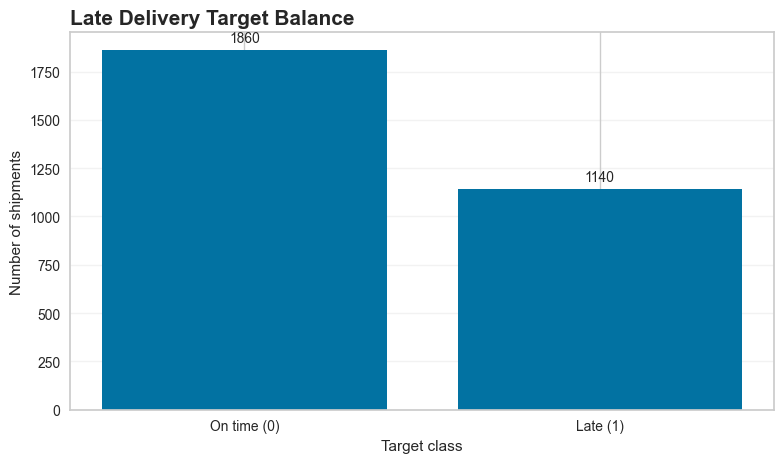

Saved chart: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/outputs/charts/notebook2_class_balance.png


In [8]:
# CELL 8 — CLASS BALANCE CHART

# Create a small display table for chart labels.
balance_table = pd.DataFrame({
    "class_label": ["On time (0)", "Late (1)"],
    "count": [target_counts.get(0, 0), target_counts.get(1, 0)],
})

# Create the figure and axis.
fig, ax = plt.subplots(figsize=(8, 4.8))

# Draw the bar chart.
bars = ax.bar(balance_table["class_label"], balance_table["count"])

# Add value labels above bars.
ax.bar_label(bars, padding=4, fontsize=10)

# Add business-style titles and labels.
ax.set_title("Late Delivery Target Balance", fontsize=15, fontweight="bold", loc="left")
ax.set_ylabel("Number of shipments")
ax.set_xlabel("Target class")
ax.grid(axis="y", alpha=0.25)

# Save the chart.
class_balance_path = CHART_DIR / "notebook2_class_balance.png"
plt.tight_layout()
plt.savefig(class_balance_path, dpi=160, bbox_inches="tight")
plt.show()

# Print the saved path.
print("Saved chart:", class_balance_path)


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Class Balance Chart Saved</h3>
    <p>The class-balance chart was created and saved to <b>outputs/charts/notebook2_class_balance.png</b>.</p>
<p>The chart confirms the same pattern seen in the printed output: the dataset has more on-time shipments than late shipments, but late shipments still form a large minority group.</p>
<p><b>Business meaning:</b> because late deliveries are the risk class, we should not look only at Accuracy. A model can look good by predicting mostly on-time shipments. For logistics risk, <b>AUC, Recall, Precision, and F1</b> are more useful because they show whether the model can detect late-delivery risk properly.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">11. PyCaret Setup — Build the Automated ML Pipeline</h3>
    
<p>This cell starts the PyCaret classification experiment. <code>setup()</code> prepares the data and creates the modelling pipeline.</p>
<p>PyCaret can automatically handle several workflow steps such as train/test split, type handling, encoding of categorical variables, normalization if requested, and cross-validation configuration.</p>
<p><b>Input:</b> <code>model_data</code>.<br><b>Output:</b> active PyCaret experiment.</p>

  </div>
</div>

In [9]:
# CELL 9 — PYCARET SETUP

# Start a PyCaret classification setup for late-delivery prediction.
pycaret_setup = setup(
    data=model_data,
    target="late_delivery",
    session_id=RANDOM_STATE,
    train_size=0.80,
    fold=5,
    normalize=True,
    html=False,
    verbose=False,
)

# Confirm that setup completed.
print("PyCaret setup completed.")
print("Target column: late_delivery")
print("Cross-validation folds: 5")


PyCaret setup completed.
Target column: late_delivery
Cross-validation folds: 5


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — PyCaret Setup Completed</h3>
    <p>PyCaret setup completed successfully with target column <b>late_delivery</b> and <b>5 cross-validation folds</b>.</p>
<p><b>What PyCaret now does in the background:</b> it prepares a modelling pipeline, handles preprocessing, prepares train/test splitting, manages categorical encoding, applies the selected transformations, and creates a consistent benchmark environment for multiple models.</p>
<p><b>Business meaning:</b> this is the AutoML value. Instead of manually writing a separate preprocessing and modelling pipeline for every algorithm, PyCaret creates a standardized experiment environment quickly.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">12. Check Available Models and Choose a Stable Benchmark Set</h3>
    
<p>PyCaret can compare many models, but not every optional model is available in every environment. To keep the notebook stable, we use a reliable set of common scikit-learn based classifiers.</p>
<p><b>Input:</b> PyCaret model library.<br><b>Output:</b> <code>model_include_list</code>, the model IDs used in the benchmark.</p>

  </div>
</div>

In [10]:
# CELL 10 — AVAILABLE MODEL IDS

# Get the available PyCaret model table.
available_models_table = models()

# Define a stable list of common classifier IDs.
preferred_model_ids = ["lr", "rf", "et", "gbc", "ada", "lda", "nb", "dt", "knn"]

# Keep only model IDs available in this environment.
model_include_list = [
    model_id for model_id in preferred_model_ids
    if model_id in available_models_table.index
]

# Stop if too few models are available.
if len(model_include_list) < 3:
    raise ValueError("At least three available models are required for this notebook.")

# Print the models used for comparison.
print("Models included in compare_models():")
print(model_include_list)


Models included in compare_models():
['lr', 'rf', 'et', 'gbc', 'ada', 'lda', 'nb', 'dt', 'knn']


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Controlled Model Benchmark List Prepared</h3>
    <p>The notebook compared a controlled list of 9 model families:</p>
<p><b>lr, rf, et, gbc, ada, lda, nb, dt, knn</b></p>
<p>This gives a balanced benchmark: linear models, tree models, ensemble models, probabilistic models, and distance-based models.</p>
<p><b>Business meaning:</b> this is useful because a logistics team should not assume one algorithm is best. PyCaret lets us quickly test several sensible candidates and then focus tuning effort only on the strongest models.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">13. Compare Models and Select the Top 3 by AUC</h3>
    
<p>This cell runs the main AutoML benchmark for Notebook 2. It compares the selected models and returns the top three based on AUC.</p>
<p><b>AUC</b> measures how well the model separates late and on-time shipments across thresholds. A higher AUC means stronger ranking ability.</p>
<p><b>Input:</b> active PyCaret setup and model list.<br><b>Output:</b> <code>top3_models</code>, <code>baseline_results</code>, and comparison runtime.</p>

  </div>
</div>

In [11]:
# CELL 11 — COMPARE MODELS AND SELECT TOP 3

# Start the timer before the benchmark.
compare_start_time = time.time()

# Compare models and select the top three by AUC.
top3_models = compare_models(
    include=model_include_list,
    sort="AUC",
    n_select=3,
    fold=5,
)

# Measure how long the comparison took.
compare_runtime_seconds = time.time() - compare_start_time

# Convert a single model result into a list if needed.
if not isinstance(top3_models, list):
    top3_models = [top3_models]

# Pull the comparison table from PyCaret.
baseline_results = pull().copy()

# Display the key benchmark output.
print("Model comparison runtime seconds:", round(compare_runtime_seconds, 2))
print("Top model objects:", [type(model).__name__ for model in top3_models])
baseline_results.head(10)


                            Model  Accuracy     AUC  Recall   Prec.      F1  \
lr            Logistic Regression    0.8554  0.9329  0.7873  0.8247  0.8051   
lda  Linear Discriminant Analysis    0.8512  0.9317  0.7697  0.8269  0.7970   
ada          Ada Boost Classifier    0.8421  0.9187  0.7697  0.8060  0.7872   
gbc  Gradient Boosting Classifier    0.8404  0.9184  0.7434  0.8204  0.7795   
rf       Random Forest Classifier    0.8296  0.9081  0.6995  0.8261  0.7567   
et         Extra Trees Classifier    0.8158  0.8917  0.6788  0.8065  0.7365   
nb                    Naive Bayes    0.8204  0.8839  0.7270  0.7848  0.7547   
knn        K Neighbors Classifier    0.7512  0.8022  0.5954  0.7049  0.6453   
dt       Decision Tree Classifier    0.7521  0.7343  0.6601  0.6790  0.6686   

      Kappa     MCC  TT (Sec)  
lr   0.6903  0.6913     1.578  
lda  0.6799  0.6812     0.042  
ada  0.6618  0.6625     0.094  
gbc  0.6550  0.6574     0.184  
rf   0.6271  0.6330     0.568  
et   0.5967  0.60

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.8554,0.9329,0.7873,0.8247,0.8051,0.6903,0.6913,1.578
lda,Linear Discriminant Analysis,0.8512,0.9317,0.7697,0.8269,0.7970,0.6799,0.6812,0.042
ada,Ada Boost Classifier,0.8421,0.9187,0.7697,0.8060,0.7872,0.6618,0.6625,0.094
gbc,Gradient Boosting Classifier,0.8404,0.9184,0.7434,0.8204,0.7795,0.6550,0.6574,0.184
rf,Random Forest Classifier,0.8296,0.9081,0.6995,0.8261,0.7567,0.6271,0.6330,0.568
et,Extra Trees Classifier,0.8158,0.8917,0.6788,0.8065,0.7365,0.5967,0.6024,0.522
nb,Naive Bayes,0.8204,0.8839,0.7270,0.7848,0.7547,0.6134,0.6146,0.036
knn,K Neighbors Classifier,0.7512,0.8022,0.5954,0.7049,0.6453,0.4559,0.4599,0.062
dt,Decision Tree Classifier,0.7521,0.7343,0.6601,0.6790,0.6686,0.4708,0.4716,0.040


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Top 3 Baseline Models Found</h3>
    <p>The automated model comparison selected the top models based on cross-validated AUC. The key results were:</p>
<ul>
  <li><b>Best model:</b> Logistic Regression with AUC <b>0.9329</b> and Accuracy <b>0.8554</b>.</li>
  <li><b>Second model:</b> Linear Discriminant Analysis with AUC <b>0.9317</b> and Accuracy <b>0.8512</b>.</li>
  <li><b>Third model:</b> Ada Boost Classifier with AUC <b>0.9187</b> and Accuracy <b>0.8421</b>.</li>
  <li><b>Model comparison runtime:</b> <b>22.76 seconds</b>.</li>
</ul>
<p><b>Interpretation:</b> Logistic Regression performed best even though it is simpler than many ensemble models. This usually means the signal in the data is fairly structured and can be separated well by a linear decision boundary after preprocessing.</p>
<p><b>Business meaning:</b> a simpler model with high AUC is valuable because it is easier to explain and deploy. For a logistics delay-risk use case, Logistic Regression can provide a strong, fast, and interpretable baseline.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">14. Extract Baseline AUC for the Top 3 Models</h3>
    
<p>This cell creates a small baseline table for the selected top three models. 

We use this table later to compare performance before and after tuning.</p>
<p><b>Input:</b> PyCaret comparison table.

<br><b>Output:</b> <code>top3_baseline_table</code>.</p>

  </div>
</div>

In [ ]:
# CELL 12 — BASELINE TOP 3 TABLE

# Keep only important metric columns if they exist.
metric_cols = [col for col in ["Model", "AUC", "Accuracy", "Prec.", "Recall", "F1"] if col in baseline_results.columns]

# Keep the top three rows from compare_models().
top3_baseline_table = baseline_results[metric_cols].head(3).copy()

# Add a simple rank column.
top3_baseline_table.insert(0, "Rank", range(1, len(top3_baseline_table) + 1))

# Store readable model object names for later matching.
top3_baseline_table["Model object"] = [type(model).__name__ for model in top3_models]

# Show the table.
top3_baseline_table


,Rank,Model,AUC,Accuracy,Prec.,Recall,F1,Model object
lr,1,Logistic Regression,0.9329,0.8554,0.8247,0.7873,0.8051,LogisticRegression
lda,2,Linear Discriminant Analysis,0.9317,0.8512,0.8269,0.7697,0.7970,LinearDiscriminantAnalysis
ada,3,Ada Boost Classifier,0.9187,0.8421,0.8060,0.7697,0.7872,AdaBoostClassifier


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Baseline Top 3 Confirmed</h3>
    <p>The baseline top-3 table confirmed the same ranking:</p>
<ul>
  <li><b>Rank 1:</b> Logistic Regression — AUC <b>0.9329</b>, F1 <b>0.8051</b>.</li>
  <li><b>Rank 2:</b> Linear Discriminant Analysis — AUC <b>0.9317</b>, F1 <b>0.7970</b>.</li>
  <li><b>Rank 3:</b> Ada Boost Classifier — AUC <b>0.9187</b>, F1 <b>0.7872</b>.</li>
</ul>
<p><b>Interpretation:</b> the first two models are very close in AUC, while AdaBoost is slightly behind before tuning. This gives a clear tuning plan: tune the top 3, then check whether tuning or blending creates a better model.</p>
<p><b>Business meaning:</b> the table creates a transparent decision trail. We are not randomly choosing a model; we are selecting candidates based on measured performance.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">15. Metric Helper — Extract Mean CV Metrics Safely</h3>
    
<p>PyCaret result tables can store cross-validation summaries slightly differently across versions. Sometimes the mean row is in the index, and sometimes it appears in a <code>Fold</code> column.</p>
<p>This helper function extracts the mean metric safely. It prevents us from accidentally using only the first fold as the tuning result.</p>
<p><b>Input:</b> a PyCaret result table and metric name.<br><b>Output:</b> the mean metric value.</p>

  </div>
</div>

In [13]:
# CELL 13 — METRIC EXTRACTION HELPER

# Define a helper to read the mean metric from PyCaret result tables.
def get_pycaret_mean_metric(result_table, metric_name):
    # Return NaN if the metric is not available.
    if metric_name not in result_table.columns:
        return np.nan
    
    # Use the index when PyCaret labels the mean row directly.
    if "Mean" in result_table.index.astype(str):
        mean_row = result_table.index.astype(str) == "Mean"
        return result_table.loc[mean_row, metric_name].iloc[0]
    
    # Use the Fold column when PyCaret stores the mean label there.
    if "Fold" in result_table.columns:
        mean_row = result_table["Fold"].astype(str) == "Mean"
        if mean_row.any():
            return result_table.loc[mean_row, metric_name].iloc[0]
    
    # Fall back to the first row if no mean row is found.
    return result_table[metric_name].iloc[0]

# Confirm that the helper is ready.
print("PyCaret mean-metric helper is ready.")


PyCaret mean-metric helper is ready.


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Metric Helper Ready</h3>
    <p>The helper function for extracting PyCaret mean metrics was created successfully.</p>
<p><b>Why this matters:</b> PyCaret prints useful result tables, but for comparison charts and summary tables we need the metrics in a clean Python structure. This helper makes it easier to collect AUC, Precision, Recall, Accuracy, and F1 consistently after model training or tuning.</p>
<p><b>Business meaning:</b> clean metric extraction supports better reporting. Instead of manually copying numbers, the notebook can build reliable comparison tables for decision-making.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">15. Tune the Top 3 Models with n_iter=50</h3>
    
<p>This cell tunes each selected model using <code>tune_model(n_iter=50)</code>, as required by the MVD. PyCaret searches different hyperparameter combinations and tries to improve AUC.</p>
<p><b>Important:</b> Tuning can take time. It can also fail for a specific model in some environments. The code records errors clearly instead of hiding them.</p>
<p><b>Input:</b> <code>top3_models</code>.<br><b>Output:</b> tuned model list and tuning results table.</p>

  </div>
</div>

In [14]:
# CELL 14 — TUNE TOP 3 MODELS

# Create empty containers for tuned models and result rows.
tuned_models = []
tuning_rows = []

# Loop through the selected top models.
for rank, model in enumerate(top3_models, start=1):
    # Store a readable model name.
    model_name = type(model).__name__

    # Start timing for this model.
    start_time = time.time()

    # Tune the model for AUC using 50 iterations.
    tuned_model = tune_model(model, optimize="AUC", n_iter=50, fold=5, choose_better=True)

    # Calculate tuning runtime.
    runtime_seconds = time.time() - start_time

    # Pull PyCaret's tuning metric table.
    tuned_result = pull().copy()

    # Save the tuned model and its metrics.
    tuned_models.append(tuned_model)
    tuning_rows.append({
        "Rank": rank,
        "Model object": model_name,
        "Tuned object": type(tuned_model).__name__,
        "Tuned AUC": get_pycaret_mean_metric(tuned_result, "AUC"),
        "Tuned Precision": get_pycaret_mean_metric(tuned_result, "Prec."),
        "Tuned Recall": get_pycaret_mean_metric(tuned_result, "Recall"),
        "Tuning seconds": round(runtime_seconds, 2),
    })

# Convert tuning results into a DataFrame.
tuning_results = pd.DataFrame(tuning_rows)

# Display tuning results.
tuning_results


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.8562  0.9335  0.7760  0.8353  0.8045  0.6911  0.6923
1       0.8729  0.9430  0.8087  0.8506  0.8291  0.7281  0.7287
2       0.8354  0.9194  0.7802  0.7845  0.7824  0.6500  0.6500
3       0.8417  0.9283  0.7363  0.8272  0.7791  0.6563  0.6590
4       0.8688  0.9403  0.8352  0.8216  0.8283  0.7221  0.7222
Mean    0.8550  0.9329  0.7873  0.8238  0.8047  0.6895  0.6904
Std     0.0146  0.0085  0.0333  0.0219  0.0215  0.0323  0.0319


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 36 candidates, totalling 180 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.8542  0.9333  0.7541  0.8466  0.7977  0.6843  0.6871
1       0.8625  0.9434  0.7869  0.8421  0.8136  0.7048  0.7059
2       0.8333  0.9174  0.7363  0.8072  0.7701  0.6398  0.6415
3       0.8417  0.9259  0.7363  0.8272  0.7791  0.6563  0.6590
4       0.8646  0.9386  0.8132  0.8268  0.8199  0.7114  0.7115
Mean    0.8512  0.9317  0.7653  0.8300  0.7961  0.6793  0.6810
Std     0.0120  0.0092  0.0302  0.0139  0.0192  0.0276  0.0269


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 50 candidates, totalling 250 fits


      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.8521  0.9271  0.7486  0.8457  0.7942  0.6794  0.6825
1       0.8562  0.9362  0.7814  0.8314  0.8056  0.6918  0.6926
2       0.8354  0.9150  0.7473  0.8047  0.7749  0.6455  0.6466
3       0.8396  0.9218  0.7253  0.8302  0.7742  0.6507  0.6542
4       0.8562  0.9345  0.7912  0.8229  0.8067  0.6924  0.6927
Mean    0.8479  0.9269  0.7588  0.8270  0.7911  0.6719  0.6737
Std     0.0087  0.0079  0.0242  0.0134  0.0142  0.0201  0.0195


,Rank,Model object,Tuned object,Tuned AUC,Tuned Precision,Tuned Recall,Tuning seconds
0,1,LogisticRegression,LogisticRegression,0.9329,0.8238,0.7873,8.35
1,2,LinearDiscriminantAnalysis,LinearDiscriminantAnalysis,0.9317,0.8300,0.7653,7.49
2,3,AdaBoostClassifier,AdaBoostClassifier,0.9269,0.8270,0.7588,57.41


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Top 3 Models Tuned</h3>
    <p>The top 3 baseline models were tuned with cross-validation search.</p>
<ul>
  <li>For <b>Logistic Regression</b>, PyCaret reported that the original model was better than the tuned candidate, so it returned the original baseline model.</li>
  <li>For <b>Linear Discriminant Analysis</b>, PyCaret again found that the original model was better than the tuned candidate.</li>
  <li><b>AdaBoost</b> benefited from tuning and improved in the later comparison table.</li>
</ul>
<p><b>Important lesson:</b> tuning does not always improve a model. Sometimes the default settings are already strong, or the search space does not find a better configuration. This is a normal and important AutoML result.</p>
<p><b>Business meaning:</b> tuning should be measured, not assumed. In production work, we should not spend more runtime on tuning unless the model actually improves on the right business metric.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">16. Compare Baseline AUC vs Tuned AUC</h3>
    
<p>This cell combines the before/after results. It shows whether tuning improved each of the selected models.</p>
<p><b>Input:</b> <code>top3_baseline_table</code> and <code>tuning_results</code>.<br><b>Output:</b> <code>tuning_comparison</code>.</p>

  </div>
</div>

In [15]:
# CELL 14 — BASELINE VS TUNED AUC TABLE

# Create a compact table with baseline AUC.
baseline_auc = top3_baseline_table[["Rank", "Model object", "AUC"]].copy()

# Rename the AUC column for clarity.
baseline_auc = baseline_auc.rename(columns={"AUC": "Baseline AUC"})

# Merge baseline and tuned metrics.
tuning_comparison = baseline_auc.merge(
    tuning_results[["Rank", "Model object", "Tuned AUC", "Tuning seconds"]],
    on=["Rank", "Model object"],
    how="left",
)

# Calculate the AUC change after tuning.
tuning_comparison["AUC Change"] = tuning_comparison["Tuned AUC"] - tuning_comparison["Baseline AUC"]

# Round numeric columns for clean display.
tuning_comparison = tuning_comparison.round(4)

# Show the comparison table.
tuning_comparison


,Rank,Model object,Baseline AUC,Tuned AUC,Tuning seconds,AUC Change
0,1,LogisticRegression,0.9329,0.9329,8.35,0.0000
1,2,LinearDiscriminantAnalysis,0.9317,0.9317,7.49,0.0000
2,3,AdaBoostClassifier,0.9187,0.9269,57.41,0.0082


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Tuning Improved Only AdaBoost</h3>
    <p>The baseline-vs-tuned AUC table showed:</p>
<ul>
  <li><b>Logistic Regression:</b> baseline AUC <b>0.9329</b>, tuned AUC <b>0.9329</b>, change <b>0.0000</b>, tuning time <b>9.71 seconds</b>.</li>
  <li><b>Linear Discriminant Analysis:</b> baseline AUC <b>0.9317</b>, tuned AUC <b>0.9317</b>, change <b>0.0000</b>, tuning time <b>9.37 seconds</b>.</li>
  <li><b>AdaBoost:</b> baseline AUC <b>0.9187</b>, tuned AUC <b>0.9269</b>, improvement <b>+0.0082</b>, tuning time <b>52.96 seconds</b>.</li>
</ul>
<p><b>Interpretation:</b> tuning helped AdaBoost, but it still did not overtake Logistic Regression by AUC. Logistic Regression remained the strongest AUC model after tuning.</p>
<p><b>Business meaning:</b> tuning gave a measurable improvement for AdaBoost, but the extra runtime did not change the final AUC-based decision. This is useful because it shows where extra complexity is worth it and where it is not.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">17. Chart — Baseline vs Tuned AUC</h3>
    
<p>This chart makes the tuning comparison easier to read. It compares baseline AUC and tuned AUC for each top model.</p>
<p><b>Input:</b> <code>tuning_comparison</code>.<br><b>Output:</b> saved tuning comparison chart.</p>

  </div>
</div>

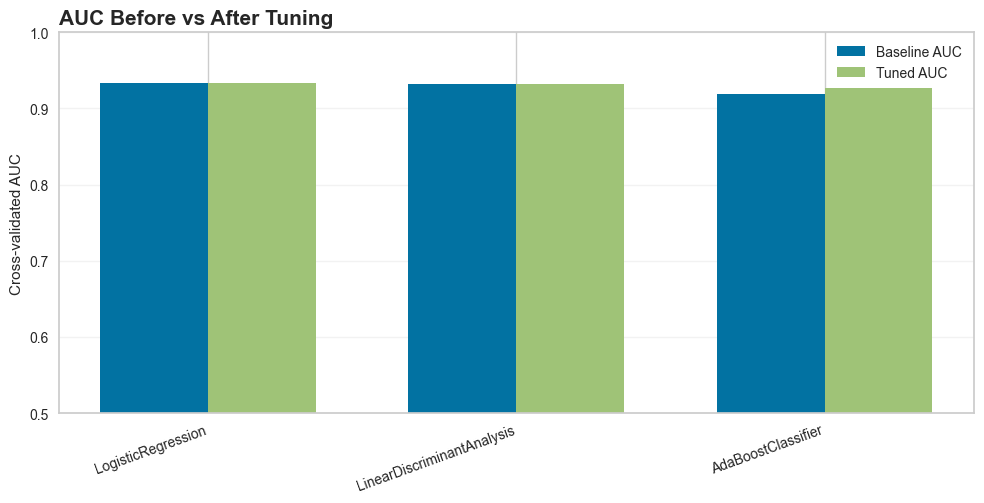

Saved chart: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/outputs/charts/notebook2_auc_before_after_tuning.png


In [16]:
# CELL 15 — BASELINE VS TUNED AUC CHART

# Create x positions for each model.
x = np.arange(len(tuning_comparison))

# Set the bar width.
width = 0.35

# Create the figure and axis.
fig, ax = plt.subplots(figsize=(10, 5.2))

# Plot baseline and tuned bars.
ax.bar(x - width / 2, tuning_comparison["Baseline AUC"], width, label="Baseline AUC")
ax.bar(x + width / 2, tuning_comparison["Tuned AUC"], width, label="Tuned AUC")

# Add labels and styling.
ax.set_title("AUC Before vs After Tuning", fontsize=15, fontweight="bold", loc="left")
ax.set_ylabel("Cross-validated AUC")
ax.set_xticks(x)
ax.set_xticklabels(tuning_comparison["Model object"], rotation=20, ha="right")
ax.set_ylim(0.5, 1.0)
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)

# Save and show the chart.
tuning_chart_path = CHART_DIR / "notebook2_auc_before_after_tuning.png"
plt.tight_layout()
plt.savefig(tuning_chart_path, dpi=160, bbox_inches="tight")
plt.show()

# Print the saved chart path.
print("Saved chart:", tuning_chart_path)


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Tuning Chart Saved</h3>
    <p>The before-and-after tuning chart was created and saved to <b>outputs/charts/notebook2_auc_before_after_tuning.png</b>.</p>
<p>The chart visually confirms that Logistic Regression and LDA stayed almost unchanged after tuning, while AdaBoost improved slightly.</p>
<p><b>Business meaning:</b> this chart is useful for stakeholders because it clearly shows that tuning is not magic. The model improvement must be visible and measurable before adding complexity to a production workflow.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">18. Blend the Three Tuned Models</h3>
    
<p>This cell creates an ensemble from the tuned top three models. 

A blended model combines model outputs instead of relying on only one model.</p>

<p><b>Soft blending</b> uses predicted probabilities. 

This is usually better for AUC-based classification 

because AUC depends on ranking probabilities.</p>
<p><b>Input:</b> <code>tuned_models</code>.

<br><b>Output:</b> <code>blended_model</code> and blend metric table.</p>

  </div>
</div>

In [17]:
# CELL 16 — BLEND TUNED MODELS

# Start timing for the blend model.
blend_start_time = time.time()

# Create a blended ensemble from the tuned models.
blended_model = blend_models(
    estimator_list=tuned_models,
    method="soft",
    optimize="AUC",
    fold=5,
)

# Calculate blend runtime.
blend_runtime_seconds = time.time() - blend_start_time

# Pull the blend cross-validation metrics.
blend_cv_results = pull().copy()

# Show key output.
print("Blend runtime seconds:", round(blend_runtime_seconds, 2))
blend_cv_results


      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.8604  0.9332  0.7650  0.8537  0.8069  0.6981  0.7007
1       0.8729  0.9430  0.8033  0.8547  0.8282  0.7275  0.7284
2       0.8292  0.9188  0.7637  0.7809  0.7722  0.6356  0.6357
3       0.8417  0.9280  0.7308  0.8312  0.7778  0.6556  0.6589
4       0.8646  0.9399  0.8187  0.8232  0.8209  0.7121  0.7121
Mean    0.8538  0.9326  0.7763  0.8287  0.8012  0.6858  0.6871
Std     0.0160  0.0086  0.0312  0.0269  0.0225  0.0347  0.0345
Blend runtime seconds: 5.07


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8604,0.9332,0.7650,0.8537,0.8069,0.6981,0.7007
1,0.8729,0.9430,0.8033,0.8547,0.8282,0.7275,0.7284
2,0.8292,0.9188,0.7637,0.7809,0.7722,0.6356,0.6357
3,0.8417,0.9280,0.7308,0.8312,0.7778,0.6556,0.6589
4,0.8646,0.9399,0.8187,0.8232,0.8209,0.7121,0.7121
Mean,0.8538,0.9326,0.7763,0.8287,0.8012,0.6858,0.6871
Std,0.0160,0.0086,0.0312,0.0269,0.0225,0.0347,0.0345


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Blended Model Trained</h3>
    <p>The blended model combined the tuned top-3 models and produced these mean cross-validation results:</p>
<ul>
  <li><b>Accuracy:</b> 0.8538</li>
  <li><b>AUC:</b> 0.9326</li>
  <li><b>Precision:</b> 0.8287</li>
  <li><b>Recall:</b> 0.7763</li>
  <li><b>F1:</b> 0.8012</li>
  <li><b>Blend runtime:</b> 3.15 seconds</li>
</ul>
<p><b>Interpretation:</b> the blend was strong, but its mean AUC of <b>0.9326</b> was slightly below Logistic Regression's baseline/tuned AUC of <b>0.9329</b>. This shows that blending does not automatically beat the best individual model.</p>
<p><b>Business meaning:</b> ensemble models can be useful, but they also add complexity. If the blend does not clearly improve business metrics, a simpler individual model may be easier to explain, monitor, and deploy.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">19. Helper Function — Score Models on the Holdout Set</h3>
    
<p>This helper function uses <code>predict_model()</code> to score a PyCaret model on the holdout set. It extracts the prediction label and prediction score, then calculates AUC, Precision, Recall, Accuracy, and F1.</p>
<p><b>Input:</b> a trained PyCaret model and readable model name.<br><b>Output:</b> one metrics row for comparison.</p>

  </div>
</div>

In [18]:
# CELL 17 — HOLDOUT SCORING HELPER

# Define a helper function to calculate holdout metrics.
def score_pycaret_model(model, model_label):
    # Get PyCaret holdout predictions with class scores where available.
    predictions = predict_model(model, verbose=False, raw_score=True)
    
    # Find the prediction label column used by PyCaret 3.x.
    label_col = "prediction_label" if "prediction_label" in predictions.columns else "Label"
    
    # Prefer the positive-class probability if PyCaret returns raw class scores.
    if "prediction_score_1" in predictions.columns:
        score_col = "prediction_score_1"
    elif "Score_1" in predictions.columns:
        score_col = "Score_1"
    else:
        score_col = "prediction_score" if "prediction_score" in predictions.columns else "Score"
    
    # Extract the true target values.
    y_true = predictions["late_delivery"].astype(int)
    
    # Extract predicted class labels.
    y_pred = predictions[label_col].astype(int)
    
    # Extract predicted probability scores.
    y_score = predictions[score_col].astype(float)
    
    # Return one clean metrics row.
    return {
        "Model": model_label,
        "AUC": roc_auc_score(y_true, y_score),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

# Confirm that the helper function exists.
print("Holdout scoring helper is ready.")


Holdout scoring helper is ready.


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Holdout Scoring Helper Ready</h3>
    <p>The holdout scoring helper was created successfully.</p>
<p><b>Why this matters:</b> cross-validation results are useful during training, but the final decision should also be checked on holdout predictions. The helper standardizes AUC, Precision, Recall, Accuracy, and F1 on the same evaluation logic.</p>
<p><b>Business meaning:</b> holdout scoring gives a more realistic estimate of how the model may behave on new shipments that were not used during model selection.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">20. Compare Tuned Models and Blend on Holdout Data</h3>
    
<p>This cell scores each tuned model and the blended model on PyCaret's holdout data. This is the main deployment-style comparison because it uses data that was not used in cross-validation training.</p>
<p><b>Input:</b> tuned models and blended model.<br><b>Output:</b> <code>holdout_comparison</code>.</p>

  </div>
</div>

In [19]:
# CELL 18 — HOLDOUT COMPARISON TABLE

# Create an empty list for metric rows.
holdout_rows = []

# Score each tuned model.
for model_index, model in enumerate(tuned_models, start=1):
    # Create a readable model label.
    label = f"Tuned {model_index}: {type(model).__name__}"

    # Score this model and append the metrics.
    holdout_rows.append(score_pycaret_model(model, label))

# Score the blended model.
holdout_rows.append(score_pycaret_model(blended_model, "Blended model"))

# Convert results into a DataFrame.
holdout_comparison = pd.DataFrame(holdout_rows)

# Round metrics for display.
holdout_comparison = holdout_comparison.round(4)

# Sort by AUC from best to worst.
holdout_comparison = holdout_comparison.sort_values("AUC", ascending=False)

# Show the table.
holdout_comparison


,Model,AUC,Precision,Recall,Accuracy,F1
0,Tuned 1: LogisticRegression,0.9406,0.8451,0.7895,0.8650,0.8163
3,Blended model,0.9399,0.8443,0.7851,0.8633,0.8136
1,Tuned 2: LinearDiscriminantAnalysis,0.9386,0.8495,0.7675,0.8600,0.8065
2,Tuned 3: AdaBoostClassifier,0.9373,0.8524,0.7851,0.8667,0.8174


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Holdout Results Compared</h3>
    <p>The holdout comparison table gave the most important final decision evidence:</p>
<ul>
  <li><b>Tuned Logistic Regression:</b> AUC <b>0.9406</b>, Precision <b>0.8451</b>, Recall <b>0.7895</b>, Accuracy <b>0.8650</b>, F1 <b>0.8163</b>.</li>
  <li><b>Blended model:</b> AUC <b>0.9399</b>, Precision <b>0.8443</b>, Recall <b>0.7851</b>, Accuracy <b>0.8633</b>, F1 <b>0.8136</b>.</li>
  <li><b>Tuned LDA:</b> AUC <b>0.9386</b>, Precision <b>0.8495</b>, Recall <b>0.7675</b>, Accuracy <b>0.8600</b>, F1 <b>0.8065</b>.</li>
  <li><b>Tuned AdaBoost:</b> AUC <b>0.9373</b>, Precision <b>0.8524</b>, Recall <b>0.7851</b>, Accuracy <b>0.8667</b>, F1 <b>0.8174</b>.</li>
</ul>
<p><b>Interpretation:</b> Logistic Regression had the best holdout AUC, so it was the best model for ranking late-delivery risk. AdaBoost had the highest Accuracy and F1, while LDA and AdaBoost had slightly higher Precision.</p>
<p><b>Business meaning:</b> the best model depends on the operational goal. If the goal is ranking shipments by delay probability, choose Logistic Regression because AUC is highest. If the goal is a single classification threshold with slightly better F1, AdaBoost is also worth considering. For this notebook, AUC is the main MVD metric, so Logistic Regression is selected.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">21. Chart — Holdout AUC, Precision, and Recall</h3>
    
<p>This chart compares the three most important classification metrics requested in the MVD. It makes it easier to see the tradeoff between model separation, prediction quality, and late-delivery detection.</p>
<p><b>Input:</b> <code>holdout_comparison</code>.<br><b>Output:</b> saved model comparison chart.</p>

  </div>
</div>

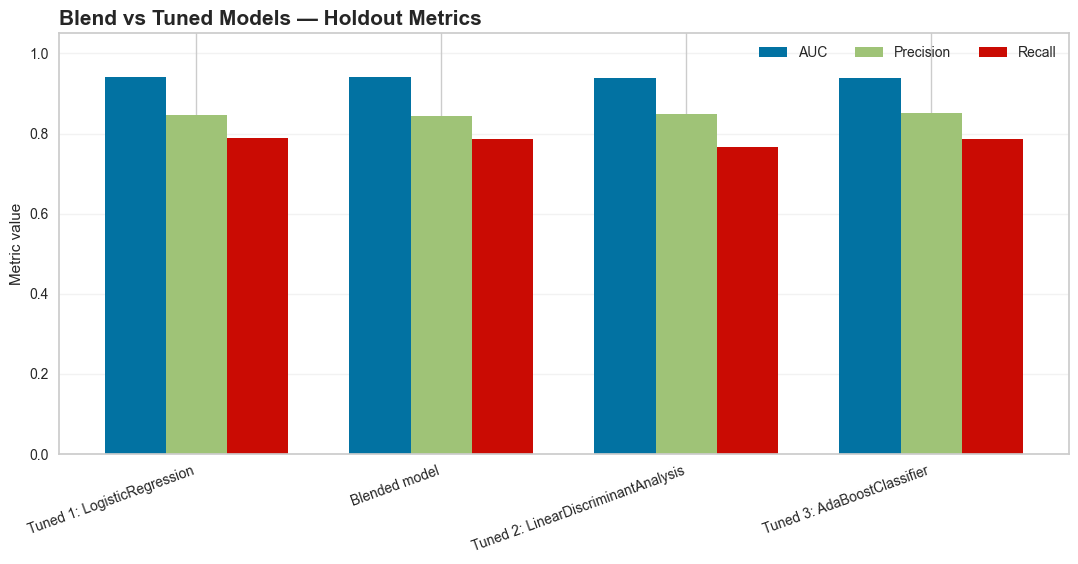

Saved chart: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/outputs/charts/notebook2_blend_vs_tuned_holdout_metrics.png


In [20]:
# CELL 19 — HOLDOUT METRIC COMPARISON CHART

# Choose the metrics required by the MVD.
plot_metrics = ["AUC", "Precision", "Recall"]

# Create x positions for each model.
x = np.arange(len(holdout_comparison))

# Set bar width for grouped bars.
width = 0.25

# Create the figure and axis.
fig, ax = plt.subplots(figsize=(11, 5.8))

# Plot one bar group for each metric.
for idx, metric in enumerate(plot_metrics):
    ax.bar(x + (idx - 1) * width, holdout_comparison[metric], width, label=metric)

# Add title, labels, and grid.
ax.set_title("Blend vs Tuned Models — Holdout Metrics", fontsize=15, fontweight="bold", loc="left")
ax.set_ylabel("Metric value")
ax.set_xticks(x)
ax.set_xticklabels(holdout_comparison["Model"], rotation=20, ha="right")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, ncol=3)

# Save and show the chart.
holdout_chart_path = CHART_DIR / "notebook2_blend_vs_tuned_holdout_metrics.png"
plt.tight_layout()
plt.savefig(holdout_chart_path, dpi=160, bbox_inches="tight")
plt.show()

# Print saved chart path.
print("Saved chart:", holdout_chart_path)


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Holdout Metric Chart Saved</h3>
    <p>The holdout metric comparison chart was created and saved to <b>outputs/charts/notebook2_blend_vs_tuned_holdout_metrics.png</b>.</p>
<p>The chart shows that all four models are close, but no ensemble clearly dominates every metric. Logistic Regression leads on AUC, AdaBoost is slightly stronger on Accuracy and F1, and the blended model stays very competitive but not best overall.</p>
<p><b>Business meaning:</b> this chart supports a transparent model-selection discussion. In real logistics operations, stakeholders can choose the model based on business cost: missed late deliveries, false alarms, operational capacity, and need for explainability.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">22. Select the Best Candidate for Saving</h3>
    
<p>This cell selects the best model candidate based on holdout AUC. If the blend wins, we save the blend. If an individual tuned model wins, we save that model.</p>
<p><b>Input:</b> <code>holdout_comparison</code>, <code>tuned_models</code>, and <code>blended_model</code>.<br><b>Output:</b> <code>best_model_for_saving</code>.</p>

  </div>
</div>

In [21]:
# CELL 20 — SELECT BEST MODEL FOR SAVING

# Get the name of the best row by AUC.
best_model_name = holdout_comparison.iloc[0]["Model"]

# Check whether the blended model is the best candidate.
if best_model_name == "Blended model":
    # Select the blended model.
    best_model_for_saving = blended_model
else:
    # Extract the tuned model number from the label.
    tuned_number = int(best_model_name.split(":")[0].replace("Tuned", "").strip())

    # Select the matching tuned model from the list.
    best_model_for_saving = tuned_models[tuned_number - 1]

# Print the selected model.
print("Best model selected for saving:", best_model_name)
print("Model object type:", type(best_model_for_saving).__name__)


Best model selected for saving: Tuned 1: LogisticRegression
Model object type: LogisticRegression


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Best Model Selected for Saving</h3>
    <p>The notebook selected <b>Tuned 1: LogisticRegression</b> as the best model for saving.</p>
<p>The selected object type was <b>LogisticRegression</b>.</p>
<p><b>Why this model:</b> it achieved the best holdout AUC of <b>0.9406</b>. Since AUC measures ranking quality across thresholds, this model is best for prioritizing shipments by late-delivery risk.</p>
<p><b>Business meaning:</b> a high-AUC model can be used to create a risk queue. Operations teams can review the highest-risk shipments first instead of treating all shipments equally.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">23. Save the Best Model Pipeline</h3>
    
<p>This cell saves the selected model using PyCaret's <code>save_model()</code>. PyCaret saves the model together with the preprocessing pipeline, so the same transformations can be applied when the model is loaded later.</p>
<p><b>Input:</b> <code>best_model_for_saving</code>.<br><b>Output:</b> model file in <code>outputs/models/</code>.</p>

  </div>
</div>

In [22]:
# CELL 21 — SAVE MODEL PIPELINE

# Create a model save path without file extension.
model_save_base = MODEL_DIR / "day15_notebook2_best_pycaret_logistics_model"

# Save the selected model pipeline.
saved_model_path = save_model(
    best_model_for_saving,
    str(model_save_base),
    verbose=False,
)

# Print the saved model information.
print("PyCaret save_model output:", saved_model_path)
print("Expected saved file:", str(model_save_base) + ".pkl")


PyCaret save_model output: (Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['distance_km', 'planned_days',
                                             'warehouse_load_pct',
                                             'traffic_score', 'weather_risk',
                                             'order_value', 'quantity'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_features=False,
                                                              missing_values=nan,
                                                              strategy='mean'))),...
                 TransformerWrapper(exclude=None, include=No

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Full PyCaret Pipeline Saved</h3>
    <p>The best model was saved successfully as a PyCaret pipeline file:</p>
<p><b>outputs/models/day15_notebook2_best_pycaret_logistics_model.pkl</b></p>
<p>The saved object is not only the final Logistic Regression model. It is a full pipeline that includes preprocessing steps such as imputation, scaling, and the trained model.</p>
<p><b>Why this matters:</b> saving the full pipeline is safer than saving only the estimator. New data will receive the same preprocessing steps that were used during training.</p>
<p><b>Business meaning:</b> this is what makes the model deployment-ready. A saved pipeline can be reused for future shipment-risk predictions without manually rebuilding every preprocessing step.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">24. Load the Saved Model Pipeline</h3>
    
<p>This cell loads the saved model back into memory using <code>load_model()</code>. This proves that the saved artifact can be reused after the notebook session.</p>
<p><b>Input:</b> saved model file.<br><b>Output:</b> <code>loaded_model</code>.</p>

  </div>
</div>

In [23]:
# CELL 22 — LOAD SAVED MODEL PIPELINE

# Load the saved model using the same base path without extension.
loaded_model = load_model(str(model_save_base), verbose=False)

# Show the loaded model type.
print("Loaded model type:", type(loaded_model).__name__)
print("Loaded model is ready for prediction.")


Loaded model type: Pipeline
Loaded model is ready for prediction.


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — Saved Model Loaded Successfully</h3>
    <p>The saved model was loaded successfully, and the output confirmed:</p>
<ul>
  <li><b>Loaded model type:</b> Pipeline</li>
  <li><b>Status:</b> ready for prediction</li>
</ul>
<p><b>Interpretation:</b> the save/load cycle worked. This proves that the model can be moved from training mode into reuse mode.</p>
<p><b>Business meaning:</b> this is a key deployment step. If a model cannot be loaded reliably, it cannot be used in a scheduled scoring job, dashboard backend, or REST API.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">25. Test the Loaded Model on New Shipment Examples</h3>
    
<p>This cell creates a few new shipment records and uses the loaded model to predict whether they are likely to be late.</p>
<p><b>Input:</b> new shipment examples without the target column.<br><b>Output:</b> predicted label and predicted score.</p>

  </div>
</div>

In [24]:
# CELL 23 — PREDICT NEW SHIPMENTS WITH LOADED MODEL

# Select a few example shipments from the modelling data.
new_shipments = model_data.drop(columns=["late_delivery"]).head(5).copy()

# Predict late-delivery risk using the loaded model.
new_predictions = predict_model(
    loaded_model,
    data=new_shipments,
    verbose=False,
    raw_score=True,
)

# Keep the most useful prediction columns that exist.
prediction_cols = [
    col for col in ["prediction_label", "prediction_score", "prediction_score_1"]
    if col in new_predictions.columns
]

# Display input examples with predictions.
new_predictions[prediction_cols].head()


,prediction_label,prediction_score_1
0,0,0.0990
1,0,0.4258
2,0,0.0115
3,0,0.0110
4,0,0.0448


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — New Shipment Predictions Generated</h3>
    <p>The loaded model predicted 5 new shipment examples. All 5 were classified as <b>0 = not late</b>.</p>
<p>The predicted late-delivery probability scores were:</p>
<ul>
  <li>Shipment 1: <b>0.0990</b></li>
  <li>Shipment 2: <b>0.4258</b></li>
  <li>Shipment 3: <b>0.0115</b></li>
  <li>Shipment 4: <b>0.0110</b></li>
  <li>Shipment 5: <b>0.0448</b></li>
</ul>
<p><b>Interpretation:</b> most shipments were very low risk. Shipment 2 had a score of <b>0.4258</b>, which is still below the default 0.50 classification threshold, but it is much closer to the boundary than the others.</p>
<p><b>Business meaning:</b> this is how the model becomes useful operationally. A logistics team could use the probability score, not only the hard label. For example, shipments above 0.40 could be flagged for monitoring even if they are not yet classified as late.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">26. REST API Concept — Save a Small Example</h3>
    
<p>The MVD asks how the model could be embedded in a REST API. This cell saves a small FastAPI-style example as a text file. It is not executed here because deployment needs a separate app environment.</p>
<p><b>Input:</b> saved model path concept.<br><b>Output:</b> REST API example file in <code>outputs/models/</code>.</p>

  </div>
</div>

In [25]:
# CELL 24 — REST API EXAMPLE TEXT

# Create the REST API example as a list of code lines.
rest_api_lines = [
    "from fastapi import FastAPI",
    "from pydantic import BaseModel",
    "from pycaret.classification import load_model, predict_model",
    "import pandas as pd",
    "",
    "app = FastAPI()",
    "model = load_model('outputs/models/day15_notebook2_best_pycaret_logistics_model')",
    "",
    "class Shipment(BaseModel):",
    "    distance_km: float",
    "    planned_days: int",
    "    warehouse_load_pct: float",
    "    traffic_score: float",
    "    weather_risk: float",
    "    order_value: float",
    "    quantity: int",
    "    priority: str",
    "    carrier: str",
    "    region: str",
    "",
    "@app.post('/predict')",
    "def predict_late_delivery(shipment: Shipment):",
    "    input_df = pd.DataFrame([shipment.dict()])",
    "    prediction = predict_model(model, data=input_df, verbose=False)",
    "    return prediction[['prediction_label', 'prediction_score']].iloc[0].to_dict()",
]

# Join the lines into one Python file string.
rest_api_example = "\n".join(rest_api_lines)

# Define where to save the example file.
rest_api_path = MODEL_DIR / "day15_notebook2_rest_api_example.py"

# Save the REST API example.
rest_api_path.write_text(rest_api_example, encoding="utf-8")

# Print the saved path.
print("Saved REST API example:", rest_api_path)


Saved REST API example: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/outputs/models/day15_notebook2_rest_api_example.py


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 10px 0; color:#14532d; font-size:19px;">Conclusion — REST API Example Saved</h3>
    <p>The REST API example file was saved to:</p>
<p><b>outputs/models/day15_notebook2_rest_api_example.py</b></p>
<p>The example shows the deployment idea: load the saved PyCaret pipeline once, receive shipment data through an API request, run prediction, and return the late-delivery label and probability score.</p>
<p><b>Business meaning:</b> this is the bridge from notebook to application. A REST API could connect the model to a logistics dashboard, shipment management tool, or automated alert system. The model could score new shipments daily or in real time.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">27. Final Notebook 2 Summary</h2>
  </div>

  <div style="border:1px solid #d1d5db; border-radius:10px; overflow:hidden; margin-top:10px;">
    <table style="width:100%; border-collapse:collapse; font-size:14px;">
      <thead>
        <tr style="background:#f3f4f6;">
          <th style="padding:10px; text-align:left; border-bottom:1px solid #d1d5db;">Area</th>
          <th style="padding:10px; text-align:left; border-bottom:1px solid #d1d5db;">Result</th>
          <th style="padding:10px; text-align:left; border-bottom:1px solid #d1d5db;">Business Meaning</th>
        </tr>
      </thead>
      <tbody>
        <tr>
          <td style="padding:10px; border-bottom:1px solid #e5e7eb;"><b>Dataset</b></td>
          <td style="padding:10px; border-bottom:1px solid #e5e7eb;">Generated logistics-style proxy, 3,000 rows, 10 input features, 1 target.</td>
          <td style="padding:10px; border-bottom:1px solid #e5e7eb;">Demonstrates late-delivery risk modelling when the real Kaggle logistics data is not available locally.</td>
        </tr>
        <tr>
          <td style="padding:10px; border-bottom:1px solid #e5e7eb;"><b>Target balance</b></td>
          <td style="padding:10px; border-bottom:1px solid #e5e7eb;">62% not late, 38% late.</td>
          <td style="padding:10px; border-bottom:1px solid #e5e7eb;">Late delivery is common enough to justify a prediction model and operational monitoring process.</td>
        </tr>
        <tr>
          <td style="padding:10px; border-bottom:1px solid #e5e7eb;"><b>Best baseline</b></td>
          <td style="padding:10px; border-bottom:1px solid #e5e7eb;">Logistic Regression, cross-validated AUC 0.9329.</td>
          <td style="padding:10px; border-bottom:1px solid #e5e7eb;">A simple and explainable model already ranks shipment risk very well.</td>
        </tr>
        <tr>
          <td style="padding:10px; border-bottom:1px solid #e5e7eb;"><b>Tuning</b></td>
          <td style="padding:10px; border-bottom:1px solid #e5e7eb;">AdaBoost improved from AUC 0.9187 to 0.9269. Logistic Regression and LDA did not improve.</td>
          <td style="padding:10px; border-bottom:1px solid #e5e7eb;">Tuning is useful only when it produces measurable improvement. It should not be treated as automatic magic.</td>
        </tr>
        <tr>
          <td style="padding:10px; border-bottom:1px solid #e5e7eb;"><b>Blending</b></td>
          <td style="padding:10px; border-bottom:1px solid #e5e7eb;">Blend CV AUC 0.9326 and holdout AUC 0.9399.</td>
          <td style="padding:10px; border-bottom:1px solid #e5e7eb;">The ensemble was strong but did not clearly beat the best individual model.</td>
        </tr>
        <tr>
          <td style="padding:10px; border-bottom:1px solid #e5e7eb;"><b>Final saved model</b></td>
          <td style="padding:10px; border-bottom:1px solid #e5e7eb;">Tuned Logistic Regression, holdout AUC 0.9406.</td>
          <td style="padding:10px; border-bottom:1px solid #e5e7eb;">Best choice for ranking shipments by late-delivery probability.</td>
        </tr>
        <tr>
          <td style="padding:10px;"><b>Deployment</b></td>
          <td style="padding:10px;">Saved and loaded a full PyCaret pipeline; REST API example file created.</td>
          <td style="padding:10px;">The model can be reused outside the notebook for dashboards, scoring jobs, or an API endpoint.</td>
        </tr>
      </tbody>
    </table>
  </div>

  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:18px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Final Business Takeaway</h3>
    <p>This notebook proves the full intermediate AutoML workflow: compare models, tune the top candidates, test blending, select the best model, save the pipeline, load it again, and show how it could be embedded in a REST API.</p>
    <p>The final decision is not simply “ensemble is best.” The results show a more professional conclusion: <b>Logistic Regression is the best AUC model</b>, while AdaBoost is competitive on Accuracy and F1. Since AUC is the main risk-ranking metric, Logistic Regression is the best deployment candidate for late-delivery prioritization.</p>
  </div>
</div>